# Quick start: forecasting page views with Prophet

In this lesson, you will:

- prepare a time series in Prophet's required format;
- fit a [Prophet](https://facebook.github.io/prophet/) forecasting model;
- generate one year of daily predictions; and
- interpret the forecast and its uncertainty interval.

## Prophet

> Forecasting is a common data science task that helps organizations with capacity planning, goal setting, and anomaly detection. Despite its importance, there are serious challenges associated with producing reliable and high-quality forecasts—especially when there are a variety of time series and analysts with expertise in time series modeling are relatively rare.
> 
> To address these challenges, we describe a practical approach to forecasting “at scale” that combines configurable models with analyst-in-the-loop performance analysis. We propose a modular regression model with interpretable parameters that can be intuitively adjusted by analysts with domain knowledge about the time series. We describe performance analyses to compare and evaluate forecasting procedures, and automatically flag forecasts for manual review and adjustment. Tools that help analysts to use their expertise most effectively enable reliable, practical forecasting of business time series. -- [Forecasting at Scale](https://www.tandfonline.com/doi/full/10.1080/00031305.2017.1380080)

## The data: daily interest in Peyton Manning

- We will forecast daily views of [Peyton Manning's Wikipedia page](https://en.wikipedia.org/wiki/Peyton_Manning).
- This series is a useful teaching example because public interest changes over time, follows weekly and yearly patterns, and spikes around events such as playoff and Super Bowl appearances.

First we’ll fetch the data:

In [25]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
)

# Prophet needs dates as datetime objects, not strings.
df["ds"] = pd.to_datetime(df["ds"])

df

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


Notice from the above that Prophet expects the input format as [pandas](https://pandas.pydata.org/docs/) DataFrame with two columns:

- `ds` (**datestamp**) contains each observation's date or timestamp. Use a format pandas understands, preferably `YYYY-MM-DD` or `YYYY-MM-DD HH:MM:SS`.
- `y` contains the numeric quantity to forecast.
import pandas as pd

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2905 entries, 0 to 2904
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      2905 non-null   datetime64[us]
 1   y       2905 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 45.5 KB


## Pre-processing

- The [`Wikipediatrend`](https://cran.r-project.org/package=wikipediatrend) R package was used to collect the original view counts.
- The [CSV supplied by Prophet](https://github.com/facebook/prophet/blob/main/examples/example_wp_log_peyton_manning.csv) has already transformed those counts. That is: `y` is the **natural logarithm of daily page views**, not the raw number of views.

### Why is the data in Logarithmic Scale?

Daily page views are non-negative and highly skewed: an important event can produce a spike many times larger than an ordinary day. Taking the logarithm:

1. compresses extreme spikes so they do not dominate the fitted model;
2. makes the variability more consistent across low- and high-traffic periods; and
3. turns multiplicative changes on the original scale into approximately additive changes, which matches Prophet's default additive structure.

## Post-processing

The model therefore forecasts on the log scale. To interpret a prediction as approximate page views:

- Transform it back with `exp(yhat)`
- Apply the same transformation to `yhat_lower` and `yhat_upper` when interpreting the interval

## How Prophet models a time series

Prophet uses an API similar to scikit-learn:

1. create a `Prophet` instance
2. call `.fit()` with the historical data
3. call `.predict()` with the dates to forecast

In [27]:
from prophet import Prophet

### Train the model

Any settings to the forecasting procedure are passed into the constructor of the Prophet` object.

In [28]:
m = Prophet()
m.fit(df)

14:13:50 - cmdstanpy - INFO - Chain [1] start processing
14:13:50 - cmdstanpy - INFO - Chain [1] done processing


Fitting should take 1-5 seconds.

### Specify future dates

- Predictions are then made on a dataframe with a column `ds` containing the dates for which a prediction is to be made.
- You can get a suitable dataframe that extends into the future a specified number of days using the helper method `Prophet.make_future_dataframe`.

In [29]:
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


Note: by default it will also include the dates from the history, so we will see the model fit as well.

So this dataframe includes both:

1. **historical dates**: until 2904	2016-01-20
2. **future dates** for 1 year; i.e., until 2017-01-19

### Predict

- The `predict` method will assign each row in `future` a predicted value which it names `yhat`.
- If you pass in historical dates, it will provide an in-sample fit.

In [30]:
forecast = m.predict(future)

- The `forecast` object here is a new dataframe that includes:
  - a column `yhat` with the forecast
  - columns for components and uncertainty intervals: `yhat_lower` and `yhat_upper`.

In [31]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.210119,7.546493,8.959653
3266,2017-01-16,8.535144,7.858505,9.246873
3267,2017-01-17,8.322571,7.618500,9.047226
3268,2017-01-18,8.155201,7.408443,8.812513
3269,2017-01-19,8.167158,7.414031,8.870059


And has other features, which aren't relevant to this lessons' discussion:

In [32]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='str')

## Plot the forecast

Pass the forecast DataFrame to `Prophet.plot` to compare the observations with the fitted values and future predictions.

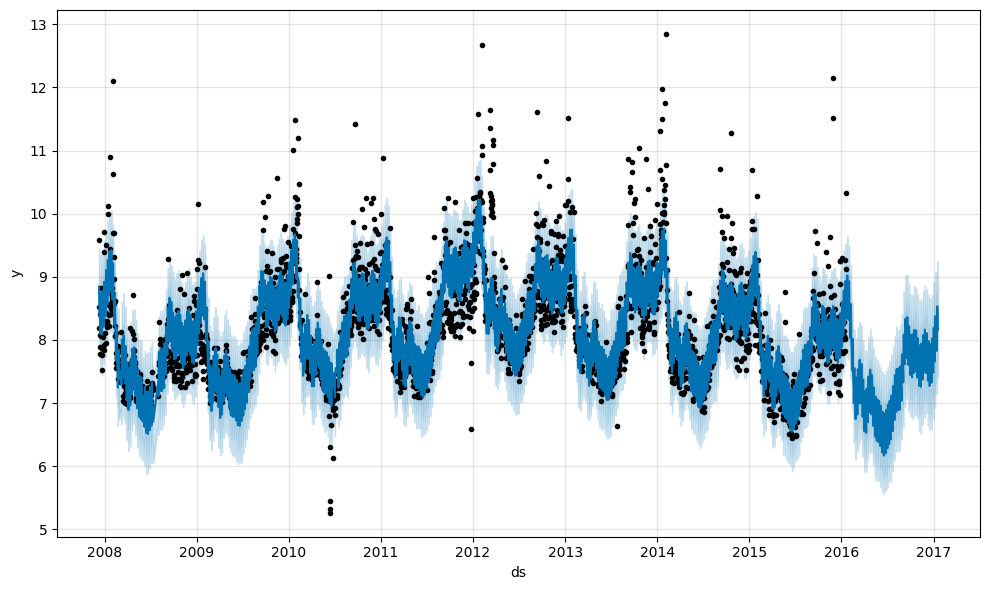

In [33]:
fig1 = m.plot(forecast)

### Interpretation of the forecast plot

**Historical Timespan** (2008 - 2016):

- (2008 - 2017) The **dark blue line** is `yhat`, Prophet's fitted value for historical dates and its forecast for future dates.
- (2008 - 2017) The **light blue band** spans `yhat_lower` to `yhat_upper`, the default uncertainty interval.
- (2008 - 2016) **Black points** are the observed daily log page views in the historical data.
  - points above or below the line correspond to bursts or dips of attention that the default model cannot explain with trend and seasonality alone. 

**Future Timespan** (2016 - 2017):

- The forecast period begins after the final black point and continues for the 365 days added to `future`.

## Forecast on the original scale

The previous plot uses log page views. To read the same forecast in daily page views, undo the log with `np.exp()` on:

- the historical `y` values that Prophet plots as black points; and
- `yhat`, `yhat_lower`, and `yhat_upper` in the forecast DataFrame.

In [35]:
import numpy as np

fcst_pageviews = forecast.copy()[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
fcst_pageviews["yhat"] = np.exp(fcst_pageviews["yhat"])
fcst_pageviews["yhat_lower"] = np.exp(fcst_pageviews["yhat_lower"])
fcst_pageviews["yhat_upper"] = np.exp(fcst_pageviews["yhat_upper"])

fcst_pageviews.tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,3677.981042,1894.088299,7782.655891
3266,2017-01-16,5090.564089,2587.649536,10372.076512
3267,2017-01-17,4115.729638,2035.507496,8494.941406
3268,2017-01-18,3481.437329,1649.856142,6717.782345
3269,2017-01-19,3523.314908,1659.100959,7115.702202


Then pass that transformed forecast to Prophet's own `plot` method. The chart below zooms to the last year of history plus the one-year forecast, and hides a few extreme spike days so typical traffic is easier to see. The model still trains on every row.

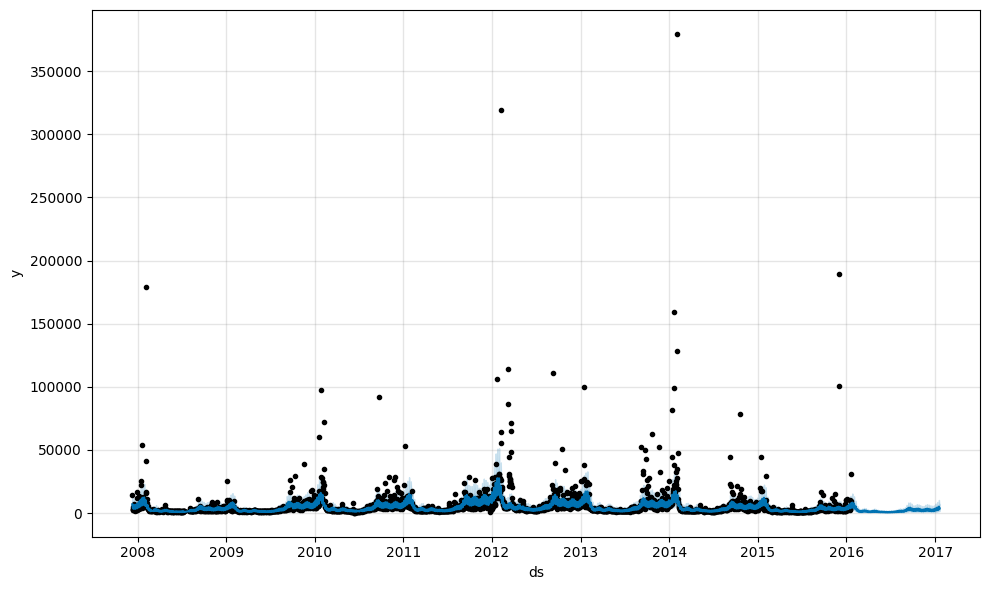

In [53]:
def plot_in_original_scale(m, fcst_pageviews):
    plot_history = m.history.copy()
    plot_history["y"] = np.exp(plot_history["y"])

    saved_history = m.history
    m.history = plot_history
    try:
        m.plot(fcst_pageviews)
    finally:
        m.history = saved_history

plot_in_original_scale(m, fcst_pageviews)

### Fix the Distortion

- Let's zoom in on the most typical values to fix the distortion.
- We will do this by only include 99% of the points (leaving the 1% extreme outliers out).

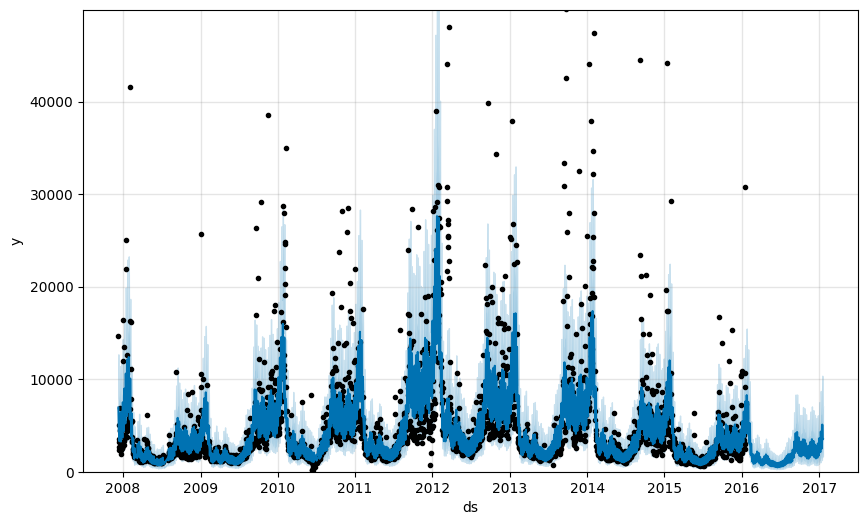

In [55]:
import matplotlib.pyplot as plt

def plot_in_original_scale(m, fcst_pageviews):
    plot_history = m.history.copy()
    plot_history["y"] = np.exp(plot_history["y"])
    
    saved_history = m.history
    m.history = plot_history
    try:
        # Filter out extreme values
        hist_max = plot_history["y"].quantile(0.99)
        fcst_max = fcst_pageviews["yhat"].quantile(0.99)
        ymax = max(hist_max, fcst_max)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.set_ylim([0, ymax])
        m.plot(fcst_pageviews, ax=ax)
    finally:
        m.history = saved_history

plot_in_original_scale(m, fcst_pageviews)